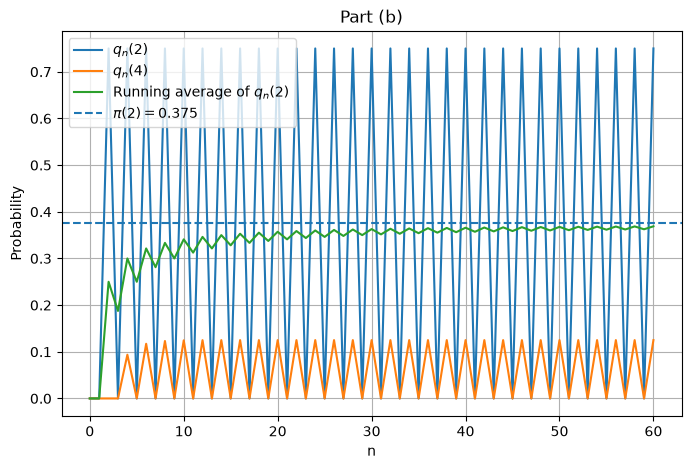

In [9]:
#Problem 1(b)
import numpy as np
import matplotlib.pyplot as plt
import os


P_b = np.array([
    [0,    1,    0,    0,    0],
    [1/4,  0,    3/4,  0,    0],
    [0,    1/2,  0,    1/2,  0],
    [0,    0,    3/4,  0,    1/4],
    [0,    0,    0,    1,    0]
])

q = np.array([1., 0, 0, 0, 0])
q_values = [q.copy()]

for _ in range(60):
    q = q @ P_b
    q_values.append(q.copy())

q_values = np.array(q_values)
n = np.arange(61)

q2 = q_values[:, 2]
q4 = q_values[:, 4]

running_average = np.cumsum(q2) / (n + 1)

plt.figure(figsize=(8, 5))

plt.plot(n, q2, label=r"$q_n(2)$")
plt.plot(n, q4, label=r"$q_n(4)$")
plt.plot(
    n,
    running_average,
    label=r"Running average of $q_n(2)$"
)

plt.axhline(
    0.375,
    linestyle="--",
    label=r"$\pi(2)=0.375$"
)

plt.xlabel("n")
plt.ylabel("Probability")
plt.title("Part (b)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.expanduser("~/Downloads/HW5 P3 1 b.pdf"), bbox_inches="tight")

plt.show()

Stationary distribution:
[0.00390625 0.046875   0.2109375  0.421875   0.31640625]

Eigenvalues:
[0.6 0.7 0.8 0.9 1. ]

First n with error < 1e-6:
n = 134
Maximum error = 9.349776264322429e-07

0.9^134 = 7.387479093976242e-07


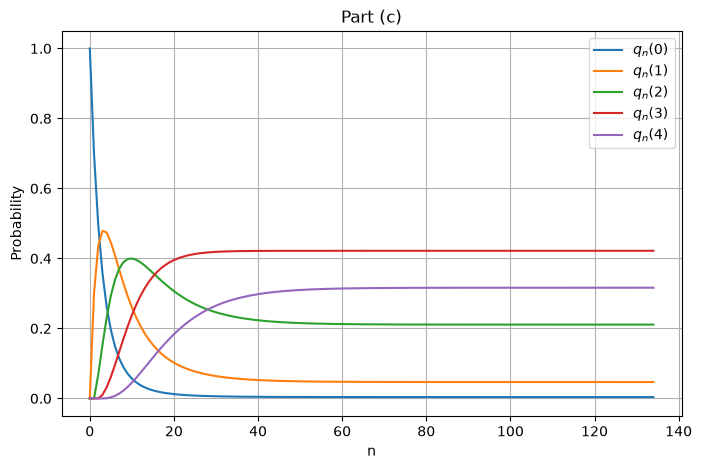

In [10]:
#Problem 1(c)


P_c = np.array([
    [0.7,   0.3,   0,     0,     0],
    [0.025, 0.75,  0.225, 0,     0],
    [0,     0.05,  0.80,  0.15,  0],
    [0,     0,     0.075, 0.85,  0.075],
    [0,     0,     0,     0.1,   0.9]
])

A = np.vstack([
    P_c.T - np.eye(5),
    np.ones(5)
])

rhs = np.array([0, 0, 0, 0, 0, 1], dtype=float)

pi, *_ = np.linalg.lstsq(A, rhs, rcond=None)

print("Stationary distribution:")
print(pi)

eigenvalues = np.linalg.eigvals(P_c)

print("\nEigenvalues:")
print(eigenvalues)

q = np.array([1., 0, 0, 0, 0])

for n in range(1000):

    error = np.max(np.abs(q - pi))

    if error < 1e-6:
        print("\nFirst n with error < 1e-6:")
        print("n =", n)
        print("Maximum error =", error)
        break

    q = q @ P_c

print("\n0.9^134 =", 0.9**134)

# Generate q_n through n = 134
q = np.array([1., 0, 0, 0, 0])
q_values = [q.copy()]

for _ in range(134):
    q = q @ P_c
    q_values.append(q.copy())

q_values = np.array(q_values)
n_values = np.arange(135)

plt.figure(figsize=(8, 5))

for k in range(5):
    plt.plot(
        n_values,
        q_values[:, k],
        label=fr"$q_n({k})$"
    )

plt.xlabel("n")
plt.ylabel("Probability")
plt.title("Part (c)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.expanduser("~/Downloads/HW5 P1 1 c.pdf"), bbox_inches="tight")

plt.show()

In [11]:

#Problem 3(a)

P = np.array([
    [0,     1/2,   1/2,   0,     0,     0,     0,     0],
    [0,     0,     1/2,   1/2,   0,     0,     0,     0],
    [1/2,   0,     0,     0,     1/2,   0,     0,     0],
    [1/3,   0,     1/3,   0,     1/3,   0,     0,     0],
    [0,     1/3,   0,     0,     0,     1/3,   1/3,   0],
    [0,     0,     0,     0,     0,     1,     0,     0],
    [0,     0,     0,     0,     0,     0,     0,     1],
    [0,     0,     0,     0,     0,     0,     1,     0]
], dtype=float)

q = np.ones(8) / 8

for n in range(1, 102):
    q = q @ P

    if n == 100:
        q100 = q.copy()

    if n == 101:
        q101 = q.copy()

print("q100 =", q100)
print("q101 =", q101)

q100 = [5.35201377e-08 5.16600068e-08 7.24662674e-08 2.99187156e-08
 5.35201377e-08 4.37499869e-01 2.67736426e-01 2.94763443e-01]
q101 = [4.62060389e-08 4.46001148e-08 6.25629775e-08 2.58300034e-08
 4.62060389e-08 4.37499887e-01 2.94763461e-01 2.67736426e-01]


In [12]:
#Problem 3(b)

d = 0.85

G = d * P + (1 - d) * np.ones((8, 8)) / 8

q = np.ones(8) / 8

for n in range(1, 10000):
    q_new = q @ G

    if np.sum(np.abs(q_new - q)) < 1e-10:
        print("Iteration count:", n)
        print("pi =", q_new)
        print("difference =", np.sum(np.abs(q_new - q)))
        break

    q = q_new

# Linear-system check
A = G.T - np.eye(8)
A[-1, :] = 1

rhs = np.zeros(8)
rhs[-1] = 1

pi = np.linalg.solve(A, rhs)

print("\nLinear solve:")
print(pi)

Iteration count: 124
pi = [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
difference = 9.566987480003064e-11

Linear solve:
[0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]


In [13]:
#Problem 3(c)

R = 100
T = 100_000
d = 0.85

# PageRank transition matrix
P = np.array([
    [0,     1/2,   1/2,   0,     0,     0,     0,     0],
    [0,     0,     1/2,   1/2,   0,     0,     0,     0],
    [1/2,   0,     0,     0,     1/2,   0,     0,     0],
    [1/3,   0,     1/3,   0,     1/3,   0,     0,     0],
    [0,     1/3,   0,     0,     0,     1/3,   1/3,   0],
    [0,     0,     0,     0,     0,     1,     0,     0],
    [0,     0,     0,     0,     0,     0,     0,     1],
    [0,     0,     0,     0,     0,     0,     1,     0]
], dtype=float)

# PageRank transition matrix with random jumps
G = d * P + (1 - d) * np.ones((8, 8)) / 8

# Stationary distribution
A = G.T - np.eye(8)
A[-1, :] = 1

rhs = np.zeros(8)
rhs[-1] = 1

pi = np.linalg.solve(A, rhs)

# CDF for discrete inverse transform sampling
cdf = np.cumsum(G, axis=1)

# Prevent floating-point round-off from causing argmax to fail
cdf[:, -1] = 1.0

rng = np.random.default_rng(2026)

# All surfers start at page 1
state = np.zeros(R, dtype=int)

# Visit counts
counts = np.zeros((R, 8), dtype=int)

T_values = np.unique(
    np.round(np.logspace(2, 5, 25)).astype(int)
)

T_set = set(T_values)
errors = []

for t in range(1, T + 1):

    # One uniform random variable per surfer
    u = rng.random(R)

    # Discrete inverse transform sampling
    state = np.argmax(
        u[:, None] <= cdf[state],
        axis=1
    )

    counts[np.arange(R), state] += 1

    if t in T_set:
        estimates = counts / t

        max_errors = np.max(
            np.abs(estimates - pi),
            axis=1
        )

        rms_error = np.sqrt(
            np.mean(max_errors**2)
        )

        errors.append(rms_error)

# One surfer's estimate
one_surfer_estimate = counts[0] / T

print("One surfer's estimate:")
print(one_surfer_estimate)

print("\nRMS error at T = 100000:")
print(errors[-1])

# Fitted slope
slope, intercept = np.polyfit(
    np.log10(T_values),
    np.log10(errors),
    1
)

print("\nFitted slope:")
print(slope)

One surfer's estimate:
[0.07067 0.06864 0.09312 0.04738 0.07216 0.25961 0.1998  0.18862]

RMS error at T = 100000:
0.004891070917026602

Fitted slope:
-0.4905111925841747


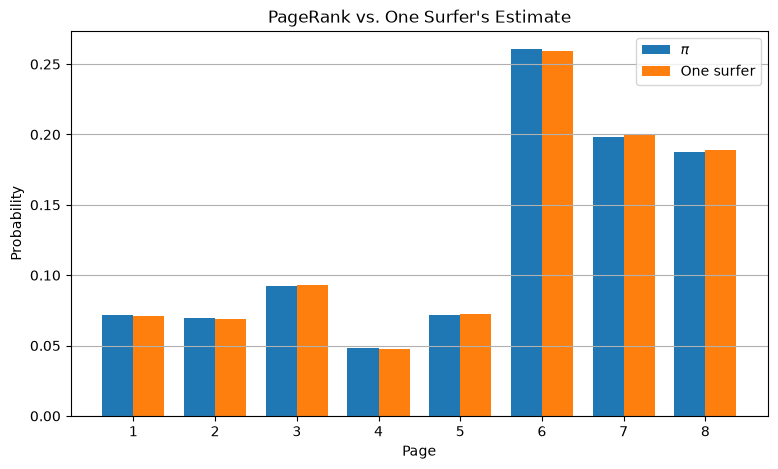

In [14]:
x = np.arange(8)
width = 0.38

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    pi,
    width,
    label=r"$\pi$"
)

plt.bar(
    x + width/2,
    one_surfer_estimate,
    width,
    label="One surfer"
)

plt.xticks(x, np.arange(1, 9))
plt.xlabel("Page")
plt.ylabel("Probability")
plt.title("PageRank vs. One Surfer's Estimate")
plt.legend()
plt.grid(axis="y")
plt.savefig(os.path.expanduser("~/Downloads/HW5 P3 1.pdf"), bbox_inches="tight")

plt.show()

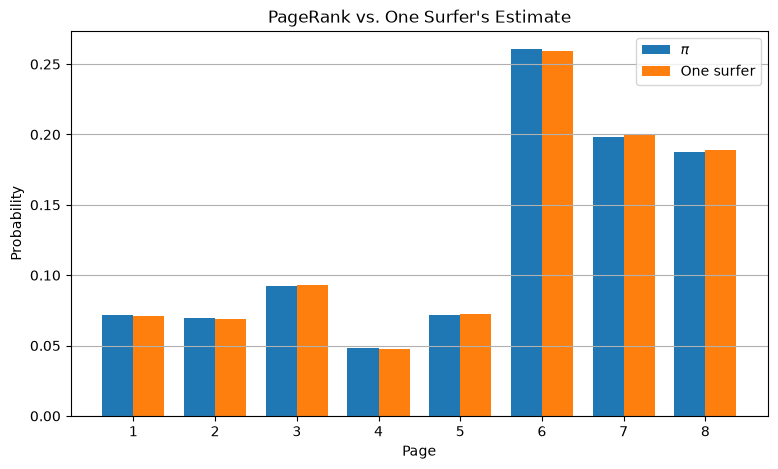

In [15]:
x = np.arange(8)
width = 0.38

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    pi,
    width,
    label=r"$\pi$"
)

plt.bar(
    x + width/2,
    one_surfer_estimate,
    width,
    label="One surfer"
)

plt.xticks(x, np.arange(1, 9))
plt.xlabel("Page")
plt.ylabel("Probability")
plt.title("PageRank vs. One Surfer's Estimate")
plt.legend()
plt.grid(axis="y")
plt.savefig(os.path.expanduser("~/Downloads/HW5 P3 2.pdf"), bbox_inches="tight")

plt.show()